# 05 - Entrenamiento Baseline

Este notebook entrena el primer modelo baseline para el problema de clasificacion binaria definido en la etapa anterior. El objetivo es estimar si un caso termina siendo grave o mortal a partir de caracteristicas de la victima y del contexto del siniestro.

## Hipotesis y problema predictivo

**Hipotesis:** Las caracteristicas de la victima y del contexto del siniestro permiten anticipar si el caso terminara siendo grave o mortal.

El problema se formula como una clasificacion binaria supervisada. La variable objetivo es `es_grave_o_mortal`, donde la clase positiva representa casos graves o mortales y la clase negativa representa casos leves.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_FILE = PROJECT_ROOT / "data" / "processed" / "siniestros_limpio_enriquecido.csv"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
METRICS_FILE = OUTPUTS_DIR / "model_metrics.json"

TARGET = "es_grave_o_mortal"
RANDOM_STATE = 42
TEST_SIZE = 0.2

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)

## Carga del dataset enriquecido

Se utiliza el dataset generado por la etapa de preprocessing y feature engineering. No se lee el dato crudo ni se modifican archivos en `data/raw/`.

In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"No se encontro {DATA_FILE}. Ejecute primero notebooks/02_preprocessing.ipynb."
    )

df = pd.read_csv(DATA_FILE, parse_dates=["fecha_siniestro"])

print(f"Dataset cargado desde: {DATA_FILE.resolve()}")
print(f"Shape: {df.shape}")
display(df.head())

Dataset cargado desde: C:\Users\Germán\Desktop\TP AVANZADA\tp-final-siniestros-viales\data\processed\siniestros_limpio_enriquecido.csv
Shape: (62076, 14)


,fecha_siniestro,anio_siniestro,modo_desplazamiento_victima,sexo_victima,edad_victima,gravedad_victima,rol_victima,edad_grupo,es_mortal,es_grave_o_mortal,vulnerabilidad_usuario,mes_siniestro,dia_semana_siniestro,trimestre_siniestro
0,2019-01-01,2019,MOTO,M,54.0,GRAVE,NaN,46_60,0,1,ALTA,1,1,1
1,2019-01-01,2019,NaN,F,1.0,LEVE,NaN,menor_18,0,0,DESCONOCIDA,1,1,1
2,2019-01-01,2019,NaN,F,21.0,LEVE,NaN,18_30,0,0,DESCONOCIDA,1,1,1
3,2019-01-01,2019,NaN,F,32.0,LEVE,NaN,31_45,0,0,DESCONOCIDA,1,1,1
4,2019-01-01,2019,NaN,F,33.0,LEVE,NaN,31_45,0,0,DESCONOCIDA,1,1,1


## Definicion de X e y

Se excluyen variables que contienen el desenlace o informacion posterior al evento. En particular, `gravedad_victima`, `GRAVEdad_victima`, `es_mortal`, `es_grave_o_mortal` y cualquier variable derivada directamente del target no se usan como feature. Esto evita data leakage y fuerza al modelo a aprender a partir de variables disponibles en el contexto del siniestro.

In [3]:
if TARGET not in df.columns:
    raise KeyError(f"No se encontro el target esperado: {TARGET}")

leakage_or_target_features = [
    "GRAVEdad_victima",
    "gravedad_victima",
    "es_mortal",
    "es_grave_o_mortal",
    "fecha_fallecimiento_victima",
]

numeric_features = [
    "anio_siniestro",
    "mes_siniestro",
    "dia_semana_siniestro",
    "trimestre_siniestro",
]

categorical_features = [
    "modo_desplazamiento_victima",
    "sexo_victima",
    "rol_victima",
    "edad_grupo",
    "vulnerabilidad_usuario",
]

numeric_features = [feature for feature in numeric_features if feature in df.columns]
categorical_features = [feature for feature in categorical_features if feature in df.columns]
selected_features = numeric_features + categorical_features

model_df = df[selected_features + [TARGET]].copy()
model_df[categorical_features] = model_df[categorical_features].fillna("SIN_DATO")

X = model_df[selected_features]
y = model_df[TARGET]

print(f"Target: {TARGET}")
print(f"Features seleccionadas: {len(selected_features)}")
display(pd.DataFrame({"feature": selected_features}))

print("Variables excluidas por target/leakage:")
display(pd.DataFrame({"variable": leakage_or_target_features, "presente_en_df": [col in df.columns for col in leakage_or_target_features]}))

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")

Target: es_grave_o_mortal
Features seleccionadas: 9


,feature
0,anio_siniestro
1,mes_siniestro
2,dia_semana_siniestro
3,trimestre_siniestro
4,modo_desplazamiento_victima
5,sexo_victima
6,rol_victima
7,edad_grupo
8,vulnerabilidad_usuario


Variables excluidas por target/leakage:


,variable,presente_en_df
0,GRAVEdad_victima,False
1,gravedad_victima,True
2,es_mortal,True
3,es_grave_o_mortal,True
4,fecha_fallecimiento_victima,False


Shape X: (62076, 9)
Shape y: (62076,)


In [4]:
feature_types = pd.DataFrame({
    "tipo": ["numerica", "categorica"],
    "variables": [numeric_features, categorical_features],
    "cantidad": [len(numeric_features), len(categorical_features)],
})

display(feature_types)
display(X.dtypes.rename("dtype").to_frame())
display(X.isna().sum().rename("nulos").to_frame())

,tipo,variables,cantidad
0,numerica,"[anio_siniestro, mes_siniestro, dia_semana_sin...",4
1,categorica,"[modo_desplazamiento_victima, sexo_victima, ro...",5


,dtype
anio_siniestro,int64
mes_siniestro,int64
dia_semana_siniestro,int64
trimestre_siniestro,int64
modo_desplazamiento_victima,object
sexo_victima,object
rol_victima,object
edad_grupo,object
vulnerabilidad_usuario,object


,nulos
anio_siniestro,0
mes_siniestro,0
dia_semana_siniestro,0
trimestre_siniestro,0
modo_desplazamiento_victima,0
sexo_victima,0
rol_victima,0
edad_grupo,0
vulnerabilidad_usuario,0


## Train/test split

El `train_test_split` separa una parte de los datos para entrenamiento y otra para evaluacion. Esto permite estimar el desempeno del modelo sobre observaciones no vistas durante el ajuste.

Se usa `stratify=y` porque el target esta desbalanceado: la clase grave o mortal es minoritaria. La estratificacion conserva proporciones similares de clases en train y test, haciendo que la evaluacion sea mas estable y comparable.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "filas": [len(X_train), len(X_test)],
    "positivos": [int(y_train.sum()), int(y_test.sum())],
    "tasa_positiva": [float(y_train.mean()), float(y_test.mean())],
})

display(split_summary)

,split,filas,positivos,tasa_positiva
0,train,49660,2465,0.049638
1,test,12416,616,0.049613


## Pipeline de sklearn

El pipeline encapsula el preprocesamiento y el modelo en un unico objeto reproducible. Las variables categoricas se transforman con `OneHotEncoder`, mientras que las numericas se pasan sin transformacion adicional mediante `passthrough`. Como modelo inicial se utiliza `LogisticRegression`, un baseline interpretable y apropiado para clasificacion binaria.

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [7]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Modelo baseline entrenado correctamente.")

Modelo baseline entrenado correctamente.


c:\Users\Germán\Desktop\TP AVANZADA\tp-final-siniestros-viales\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Evaluacion del modelo

La accuracy indica la proporcion total de aciertos, pero no es suficiente cuando existe desbalance de clases: un modelo podria acertar muchos casos leves y fallar justamente los casos graves o mortales. Por eso se reportan tambien precision, recall y F1.

La precision mide que proporcion de las predicciones positivas fue correcta. El recall mide que proporcion de los casos graves o mortales reales fue detectada. El F1 resume precision y recall en una sola metrica, util cuando se necesita balancear falsos positivos y falsos negativos.

In [8]:
metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred, zero_division=0)),
    "recall": float(recall_score(y_test, y_pred, zero_division=0)),
    "f1_score": float(f1_score(y_test, y_pred, zero_division=0)),
}

conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
class_report_text = classification_report(y_test, y_pred, zero_division=0)

display(pd.DataFrame([metrics]).T.rename(columns={0: "valor"}))
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report_text)

,valor
accuracy,0.955380
precision,1.000000
recall,0.100649
f1_score,0.182891


Confusion Matrix:
[[11800     0]
 [  554    62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     11800
           1       1.00      0.10      0.18       616

    accuracy                           0.96     12416
   macro avg       0.98      0.55      0.58     12416
weighted avg       0.96      0.96      0.94     12416



## Visualizaciones de evaluacion

La matriz de confusion permite distinguir verdaderos negativos, falsos positivos, falsos negativos y verdaderos positivos. La distribucion de predicciones ayuda a verificar si el modelo esta prediciendo ambas clases o si colapsa hacia la clase mayoritaria.

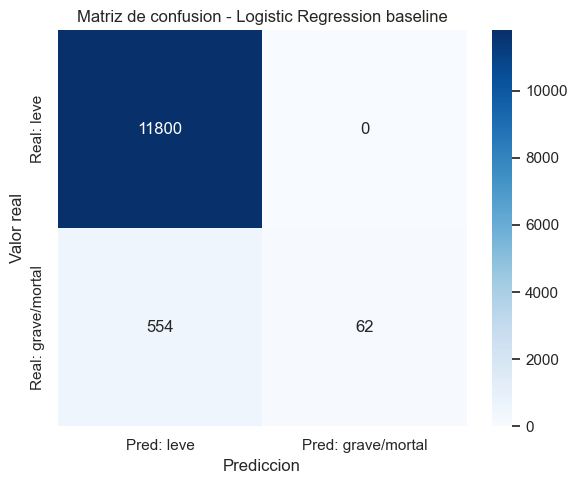

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred: leve", "Pred: grave/mortal"],
    yticklabels=["Real: leve", "Real: grave/mortal"],
    ax=ax,
)
ax.set_title("Matriz de confusion - Logistic Regression baseline")
ax.set_xlabel("Prediccion")
ax.set_ylabel("Valor real")
plt.tight_layout()
plt.show()

,clase,cantidad,porcentaje
0,0,12354,99.5
1,1,62,0.5


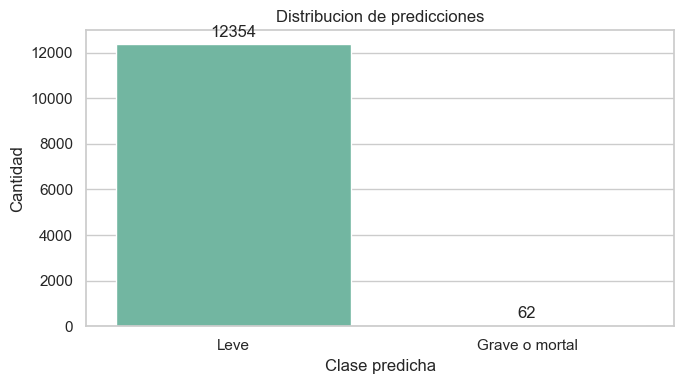

In [10]:
prediction_distribution = pd.Series(y_pred, name="prediccion").value_counts().sort_index()
prediction_distribution_pct = (prediction_distribution / len(y_pred) * 100).round(2)
prediction_summary = pd.DataFrame({
    "clase": prediction_distribution.index,
    "cantidad": prediction_distribution.values,
    "porcentaje": prediction_distribution_pct.values,
})

display(prediction_summary)

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(x=y_pred, hue=y_pred, order=[0, 1], palette="Set2", legend=False, ax=ax)
ax.set_title("Distribucion de predicciones")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Cantidad")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Leve", "Grave o mortal"])
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
plt.tight_layout()
plt.show()

## Guardado de metricas

Las metricas del baseline se guardan en `outputs/model_metrics.json` para dejar trazabilidad del primer resultado entrenado y poder compararlo en futuras iteraciones.

In [11]:
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

metrics_payload = {
    "model": "LogisticRegression",
    "target": TARGET,
    "hypothesis": "Las caracteristicas de la victima y del contexto del siniestro permiten anticipar si el caso terminara siendo grave o mortal.",
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "features": {
        "numeric": numeric_features,
        "categorical": categorical_features,
        "excluded_leakage_or_target": leakage_or_target_features,
    },
    "data": {
        "n_rows": int(len(df)),
        "n_features": int(len(selected_features)),
        "train_rows": int(len(X_train)),
        "test_rows": int(len(X_test)),
        "train_positive_rate": float(y_train.mean()),
        "test_positive_rate": float(y_test.mean()),
    },
    "metrics": metrics,
    "confusion_matrix": conf_matrix.tolist(),
    "classification_report": class_report,
    "prediction_distribution": prediction_summary.to_dict(orient="records"),
}

with METRICS_FILE.open("w", encoding="utf-8") as file:
    json.dump(metrics_payload, file, ensure_ascii=False, indent=2)

print(f"Metricas guardadas en: {METRICS_FILE.resolve()}")

Metricas guardadas en: C:\Users\Germán\Desktop\TP AVANZADA\tp-final-siniestros-viales\outputs\model_metrics.json


## Cierre

Queda entrenado un primer baseline completo con `LogisticRegression`. Este resultado no busca ser el mejor modelo posible, sino establecer una referencia reproducible para comparar proximas mejoras de feature engineering, tratamiento de faltantes, balanceo de clases, calibracion de umbral o modelos alternativos.